In [21]:
!pip install igraph
!pip install reinmax

In [22]:
import os
import time
import copy
import math
import random
import typing
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import igraph as ig

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset
from torch.distributions import MultivariateNormal

from sklearn.metrics import roc_auc_score
from reinmax import reinmax

# ==========================================
# Configuration & Seeds
# ==========================================

def set_random_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

CONFIG = {
    'seed': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'gpu_index': "3",
    'num_nodes': 20,
    'edge_num': 30,
    'n_samples': 10000,
    'batch_size': 256,
    'n_epochs': 300,
    'lr': 1e-3,
    'eps': 1e-5,
    'embed_dim': 512,
    'n_layer': 1,
    'sigma': 25.0
}

# Set device
if torch.cuda.is_available():
    os.environ['CUDA_VISIBLE_DEVICES'] = CONFIG['gpu_index']
    torch.set_default_dtype(torch.float32)

set_random_seed(CONFIG['seed'])
device = CONFIG['device']
print(f"Running on {device}")


Running on cuda


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# ==========================================
# DAG Utils
# ==========================================

def is_dag(W: np.ndarray) -> bool:
    """Returns ``True`` if ``W`` is a DAG, ``False`` otherwise."""
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()

def simulate_dag(d: int, s0: int, graph_type: str) -> np.ndarray:
    """Simulate random DAG with some expected number of edges."""
    def _random_permutation(M):
        P = np.random.permutation(np.eye(M.shape[0]))
        return P.T @ M @ P

    def _random_acyclic_orientation(B_und):
        return np.tril(_random_permutation(B_und), k=-1)

    def _graph_to_adjmat(G):
        return np.array(G.get_adjacency().data)

    if graph_type == 'ER':
        G_und = ig.Graph.Erdos_Renyi(n=d, m=s0)
        B_und = _graph_to_adjmat(G_und)
        B = _random_acyclic_orientation(B_und)
    elif graph_type == 'SF':
        G = ig.Graph.Barabasi(n=d, m=int(round(s0 / d)), directed=True)
        B = _graph_to_adjmat(G)
    elif graph_type == 'BP':
        top = int(0.2 * d)
        G = ig.Graph.Random_Bipartite(top, d - top, m=s0, directed=True, neimode=ig.OUT)
        B = _graph_to_adjmat(G)
    elif graph_type == 'Fully':
        B = np.triu(np.ones((d, d)), 1)
    else:
        raise ValueError('unknown graph type')

    B_perm = _random_permutation(B)
    assert ig.Graph.Adjacency(B_perm.tolist()).is_dag()
    return B_perm

def simulate_linear_sem(W: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from linear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, w, scale):
        if sem_type == 'gauss':
            z = np.random.normal(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'exp':
            z = np.random.exponential(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'gumbel':
            z = np.random.gumbel(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'uniform':
            z = np.random.uniform(low=-scale, high=scale, size=n)
            x = X @ w + z
        elif sem_type == 'logistic':
            x = np.random.binomial(1, sigmoid(X @ w)) * 1.0
        elif sem_type == 'poisson':
            x = np.random.poisson(np.exp(X @ w)) * 1.0
        else:
            raise ValueError('unknown sem type')
        return x

    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        scale_vec = noise_scale

    if not is_dag(W):
        raise ValueError('W must be a DAG')

    if np.isinf(n):
        if sem_type == 'gauss':
            X = np.sqrt(d) * np.diag(scale_vec) @ np.linalg.inv(np.eye(d) - W)
            return X
        else:
            raise ValueError('population risk not available')

    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    X = np.zeros([n, d])
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], W[parents, j], scale_vec[j])
    return X

def simulate_nonlinear_sem(B: np.ndarray, n: int, sem_type: str, noise_scale: typing.Optional[typing.Union[float, typing.List[float]]] = None) -> np.ndarray:
    """Simulate samples from nonlinear SEM."""
    from scipy.special import expit as sigmoid

    def _simulate_single_equation(X, scale):
        z = np.random.normal(scale=scale, size=n)
        pa_size = X.shape[1]
        if pa_size == 0:
            return z
        if sem_type == 'mlp':
            hidden = 100
            W1 = np.random.uniform(low=0.5, high=2.0, size=[pa_size, hidden])
            W1[np.random.rand(*W1.shape) < 0.5] *= -1
            W2 = np.random.uniform(low=0.5, high=2.0, size=hidden)
            W2[np.random.rand(hidden) < 0.5] *= -1
            x = sigmoid(X @ W1) @ W2 + z
        elif sem_type == 'mim':
            w1 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w1[np.random.rand(pa_size) < 0.5] *= -1
            w2 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w2[np.random.rand(pa_size) < 0.5] *= -1
            w3 = np.random.uniform(low=0.5, high=2.0, size=pa_size)
            w3[np.random.rand(pa_size) < 0.5] *= -1
            x = np.tanh(X @ w1) + np.cos(X @ w2) + np.sin(X @ w3) + z
        else:
             raise ValueError('unknown sem type')
        return x

    d = B.shape[0]
    scale_vec = noise_scale if noise_scale else np.ones(d)
    X = np.zeros([n, d])
    G = ig.Graph.Adjacency(B.tolist())
    ordered_vertices = G.topological_sorting()
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], scale_vec[j])
    return X


In [ ]:
for sample in range(5):
    for node_number in [20,30,50]:
        _graph_adj = simulate_dag(node_number, 4*node_number, 'ER')
        data = simulate_linear_sem(_graph_adj, 10000, 'gauss')
        file_name = f'data_{sample}_{node_number}.pt'
        save_path = os.path.join(save_dir, file_name)
        torch.save({
            'data': data,
            'graph_adj': _graph_adj
        }, save_path)

In [27]:
# ==========================================
# Dataset Classes
# ==========================================

class DAGDataset(Dataset):
    def __init__(self, node_num, edge_num, n_samples, linear, DAG_type, SEM_type, device, data, graph_adj):
        self._node_num = node_num
        self._edge_num = edge_num
        self.n_samples = n_samples
        self.DAG_type = DAG_type
        self.SEM_type = SEM_type
        self.device = device
        self._graph_adj = graph_adj
        self.data = data

    @property
    def node_num(self):
        return self._node_num

    @property
    def edge_num(self):
        return self._edge_num

    @property
    def graph_adj(self):
        return self._graph_adj

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.data[idx, :]


In [28]:
# ==========================================
# Model Components
# ==========================================

def new_gelu(x):
    return 0.5 * x * (1.0 + torch.tanh(math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))))

class MLP(nn.Module):
    def __init__(self, n_embd, bias=False, dropout=0.0):
        super().__init__()
        self.c_fc = nn.Linear(n_embd, 4 * n_embd, bias=bias)
        self.c_proj = nn.Linear(4 * n_embd, n_embd, bias=bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = new_gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class Dense(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.dense(x)

class SelfAttention(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=bias)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=bias)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.flash = False

    def forward(self, x, att_mask=None):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        if att_mask is not None:
            att = att * att_mask
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class EncoderLayer(nn.Module):
    def __init__(self, n_embd=768, n_head=12, bias=True, dropout=0.0):
        super().__init__()
        self.ln_1 = nn.LayerNorm(n_embd)
        self.attn = SelfAttention(n_embd=n_embd, n_head=n_head, bias=bias, dropout=dropout)
        self.ln_2 = nn.LayerNorm(n_embd)
        self.mlp = MLP(n_embd=n_embd, dropout=dropout)

    def forward(self, x, att_mask=None):
        out = self.attn(self.ln_1(x), att_mask=att_mask)
        x = x + out
        x = x + self.mlp(self.ln_2(x))
        return x

class TimeAwareResBlock(nn.Module):
    def __init__(self, embed_dim, t_emb_out_dim=None):
        super().__init__()
        self.layer = Dense(embed_dim, embed_dim)
        self.act = nn.SiLU(inplace=True)
        self.ln = nn.LayerNorm(embed_dim)
        self.t_emb = Dense(embed_dim, t_emb_out_dim if t_emb_out_dim else embed_dim)

    def forward(self, x, t_embed):
        x_res = x
        t_proj = self.t_emb(t_embed)[:, None, :]
        x = self.layer(x + t_proj)
        x = self.act(x) + x_res
        return self.ln(x)

class GraphLDiffusion(nn.Module):
    def __init__(self, input_size, embed_dim=256, n_layer=8):
        super().__init__()
        self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
                                   nn.Linear(embed_dim, embed_dim))
        self.denses = nn.ModuleList([Dense(embed_dim, embed_dim) for _ in range(n_layer)])
        self.target_embed = nn.Embedding(input_size, embed_dim)

        self.EncoderLayers = nn.ModuleList(
            [EncoderLayer(n_embd=embed_dim, n_head=32, bias=False, dropout=0.0) for _ in range(n_layer)])

        self.ln = nn.LayerNorm(embed_dim, bias=True)

        # Initial blocks (a, b, c, d)
        self.initial_blocks = nn.ModuleList([TimeAwareResBlock(embed_dim) for _ in range(4)])

        # Final blocks (a, b, c)
        self.final_blocks = nn.ModuleList([
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim),
            TimeAwareResBlock(embed_dim, t_emb_out_dim=1)
        ])

        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))


        self.act = lambda x: x * torch.sigmoid(x)
        self.att_mask_pro = nn.Parameter(torch.ones(input_size, input_size, 2))
        self.x_layer_weight = nn.Parameter(torch.ones(n_layer))

    def forward(self, x, t, targets=None):
        embed = self.act(self.embed(t))
        x = (x[:, :, None] * self.target_embed.weight[None, :, :])

        # Initial Processing
        for block in self.initial_blocks:
            x = block(x, embed)

        # Attention Mask
        attn_mask_hard, _ = reinmax(self.att_mask_pro, tau=2)
        attn_mask_hard = attn_mask_hard[:, :, 1]

        # Encoder Layers
        x_list = []
        for enc_layer, dense in zip(self.EncoderLayers, self.denses):
            x = enc_layer(x + dense(embed)[:, None, :], att_mask=attn_mask_hard)
            x_list.append(x)

        x = torch.stack(x_list, dim=0)
        x = torch.sum(x * self.x_layer_weight[:, None, None, None], dim=0)
        x = self.ln(x)

        # Final Processing
        for block in self.final_blocks:
            x = block(x, embed)

        out = x[:, :, 0]
        return out, attn_mask_hard


In [29]:
# ==========================================
# Diffusion Utils
# ==========================================

def marginal_prob_std(t, sigma):
    return torch.sqrt((sigma ** (2 * t) - 1.) / 2. / np.log(sigma))

def diffusion_coeff(t, sigma):
    return torch.tensor(sigma ** t, device=device)

marginal_prob_std_fn = functools.partial(marginal_prob_std, sigma=CONFIG['sigma'])


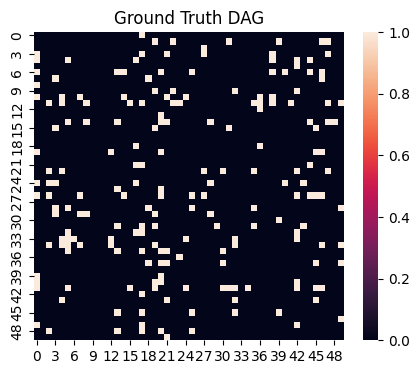

In [ ]:
# ==========================================
# Training
# ==========================================

# Prepare Data
sample = 0 # 0-4
node_num = 20
edge_num = 4*node_num
n_samples = 10000
linear = True
DAG_type = 'ER'
SEM_type = 'gauss'
device = 'cuda'
LOCAL_FOLDER = 'Path_node_num'

if not os.path.exists(LOCAL_FOLDER):
    os.makedirs(LOCAL_FOLDER)
data_path = os.path.join(LOCAL_FOLDER, f'data_{sample}_{node_num}.pt')
data_all = torch.load(data_path, weights_only=False)
data = data_all['data']
graph_adj = data_all['graph_adj']
dataset = DAGDataset(
    node_num=node_num,
    edge_num=edge_num,
    n_samples=n_samples,
    linear=linear,
    DAG_type=DAG_type,
    SEM_type=SEM_type,
    device=device,
    data=data,
    graph_adj=graph_adj
)
data_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

# Plot Ground Truth
plt.figure(figsize=(5, 4))
sns.heatmap(dataset.graph_adj)
plt.title("Ground Truth DAG")
plt.show()

In [ ]:
import numpy as np

# ==========================================
# Training Loop over Samples
# ==========================================

samples_list = range(5) # As generated in the previous cells
node_numbers_to_train = [20, 30, 50] # Node numbers for which data was generated
results = {}

print(f"Starting training for {len(node_numbers_to_train)} node configurations and {len(samples_list)} samples each...")

for current_node_num in node_numbers_to_train:
    current_edge_num = 4 * current_node_num # Adjust edge_num based on node_num
    print(f"\n====== Training for Node Number: {current_node_num} ======")

    for sample in samples_list:
        print(f"\n=== Starting Run for Sample {sample} ===")

        data_path = os.path.join(LOCAL_PATH, f'data_{sample}_{current_node_num}.pt')
        data_all = torch.load(data_path, weights_only=False)
        data = data_all['data']
        graph_adj = data_all['graph_adj']

        dataset = DAGDataset(
            node_num=current_node_num,
            edge_num=current_edge_num,
            n_samples=CONFIG['n_samples'],
            linear=True,
            DAG_type='ER',
            SEM_type='gauss',
            device=CONFIG['device'],
            data=data,
            graph_adj=graph_adj
        )
        data_loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True)

        # Initialize model with current_node_num
        score_model = GraphLDiffusion(current_node_num, embed_dim=CONFIG['embed_dim'], n_layer=CONFIG['n_layer'])
        score_model = score_model.to(device)
        optimizer = Adam(score_model.parameters(), lr=CONFIG['lr'])
        score_loss_arr = []

        for epoch in range(CONFIG['n_epochs']):
            score_model.train()
            for x in data_loader:
                x = x.to(device)
                random_t = torch.rand(x.shape[0], device=x.device) * (1. - CONFIG['eps']) + CONFIG['eps']
                random_t = random_t * 0.5
                z = torch.randn_like(x)
                std = marginal_prob_std_fn(random_t)
                perturbed_x = x + z * std[:, None]

                score, attn_mask = score_model(perturbed_x.float(), random_t)

                loss_score = torch.mean(torch.sum((score * std[:, None] + z) ** 2, dim=(1)) / score.shape[1])
                loss_sparsity = torch.sum(torch.abs(attn_mask)) * 0.005/current_node_num
                loss_all = loss_score + loss_sparsity

                score_loss_arr.append(loss_score.item())

                optimizer.zero_grad()
                loss_all.backward()
                optimizer.step()

            # Logging & Evaluation
            if epoch % 100 == 0 or epoch == CONFIG['n_epochs'] - 1:
                # Access att_mask_pro directly
                mask_hard, mask_soft = reinmax(score_model.att_mask_pro, tau=1)
                mask = mask_soft[:, :, 1].detach().cpu()

                # Calculate AUC
                index_no_d_auc = torch.eye(mask.size(0)) == 0
                off_diagonal_pred = mask[index_no_d_auc]
                off_diagonal_true = dataset.graph_adj[index_no_d_auc.numpy().astype(bool)].flatten()

                auc = roc_auc_score(off_diagonal_true, off_diagonal_pred.flatten())
                mean_score_loss = np.mean(score_loss_arr[-len(data_loader):])

                print(f'Node {current_node_num} | Sample {sample} | Epoch {epoch} | AUC: {auc:.6f} | Score Loss: {mean_score_loss:.6f}')

                # Save checkpoint periodically and at the end
                if epoch == 30:
                    plt.figure(figsize=(5, 4))
                    sns.heatmap(mask)
                    plt.title(f"Estimated DAG (Node {current_node_num}, Epoch {epoch})")
                    plt.show()
                if epoch >= CONFIG['n_epochs'] - 1:
                    # Update model_save_path to include node_num
                    model_save_path = os.path.join(LOCAL_PATH, f'checkpoint_d{current_node_num}_exp{sample}.pth')
                    torch.save(score_model.state_dict(), model_save_path)
                    break

        # Store final result in a nested dictionary
        if current_node_num not in results:
            results[current_node_num] = {}
        results[current_node_num][sample] = auc
        print(f"Finished Node {current_node_num}, Sample {sample}. Final AUC: {auc:.6f}")

print("\nAll runs completed.")
print("Final AUC Results per node number and sample:", results)

Starting training for 3 node configurations and 5 samples each...

====== Training for Node Number: 20 ======

=== Starting Run for Sample 0 ===
Node 20 | Sample 0 | Epoch 0 | AUC: 0.528958 | Score Loss: 1.140266
Node 20 | Sample 0 | Epoch 100 | AUC: 0.709792 | Score Loss: 0.684176
Node 20 | Sample 0 | Epoch 200 | AUC: 0.746583 | Score Loss: 0.641169
Node 20 | Sample 0 | Epoch 299 | AUC: 0.778875 | Score Loss: 0.620230
Finished Node 20, Sample 0. Final AUC: 0.778875

=== Starting Run for Sample 1 ===
Node 20 | Sample 1 | Epoch 0 | AUC: 0.516000 | Score Loss: 1.301223
Node 20 | Sample 1 | Epoch 100 | AUC: 0.717667 | Score Loss: 0.670894
Node 20 | Sample 1 | Epoch 200 | AUC: 0.747583 | Score Loss: 0.628826
Node 20 | Sample 1 | Epoch 299 | AUC: 0.770250 | Score Loss: 0.602472
Finished Node 20, Sample 1. Final AUC: 0.770250

=== Starting Run for Sample 2 ===
Node 20 | Sample 2 | Epoch 0 | AUC: 0.537917 | Score Loss: 1.158401
Node 20 | Sample 2 | Epoch 100 | AUC: 0.665542 | Score Loss: 0.69